In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Загрузка и структура данных

In [2]:
# Загрузка датасета
tesla_df = pd.read_csv('https://code.s3.yandex.net/datasets/tesla_historic_prices.csv')
print(tesla_df.head())
print(tesla_df.info())

         Date      Open      High       Low     Close  Adj Close     Volume
0  2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500
1  2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500
2  2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000
3  2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000
4  2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500
<class 'pandas.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       3347 non-null   str    
 1   Open       3347 non-null   float64
 2   High       3347 non-null   float64
 3   Low        3347 non-null   float64
 4   Close      3347 non-null   float64
 5   Adj Close  3347 non-null   float64
 6   Volume     3347 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 183.2 KB
None


In [3]:
# Преобразование 'Date' в datetime и установка в качестве индекса
tesla_df['Date'] = pd.to_datetime(tesla_df['Date'])
tesla_df.set_index('Date', inplace=True)
tesla_df.sort_index(inplace=True)

print(tesla_df.head())
print(f"\nНачало ряда: {tesla_df.index.min().date()}")
print(f"Конец ряда: {tesla_df.index.max().date()}")
print(f"Общее количество торговых дней: {len(tesla_df)}")

                Open      High       Low     Close  Adj Close     Volume
Date                                                                    
2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500
2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500
2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000
2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000
2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500

Начало ряда: 2010-06-29
Конец ряда: 2023-10-13
Общее количество торговых дней: 3347


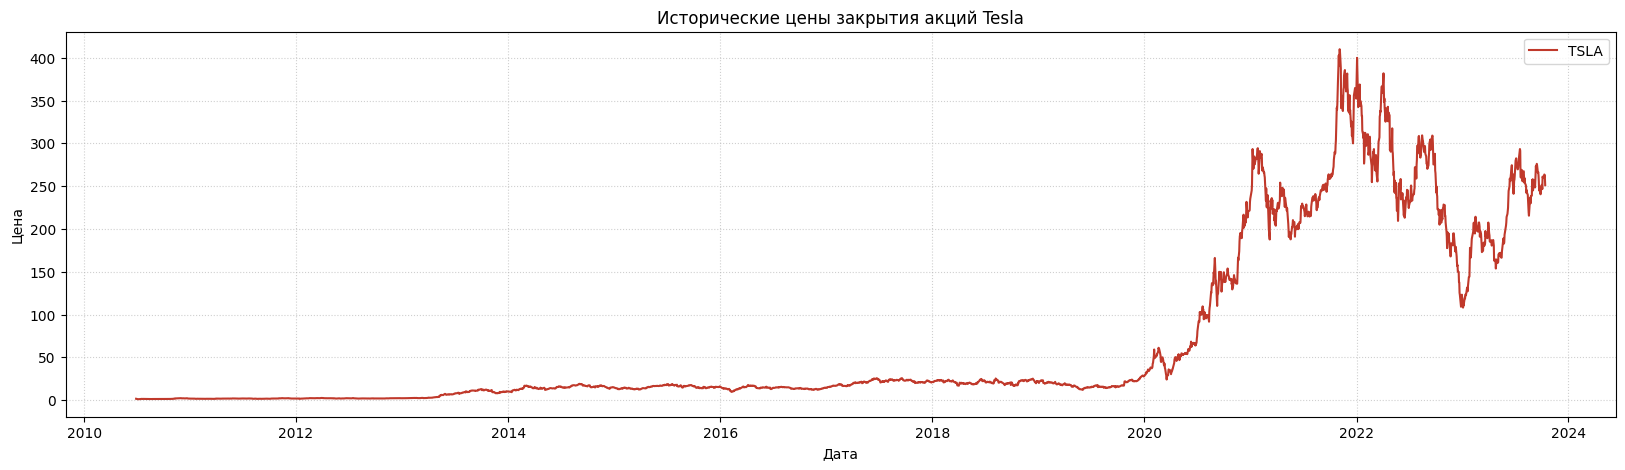

In [4]:
plt.figure(figsize=(20, 5))
plt.plot(
    tesla_df['Close'],
    label='TSLA',
    color='#C0392B',
    linewidth=1.5
)
plt.title('Исторические цены закрытия акций Tesla')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Создание признаков

In [5]:
# Создание признака High-Low
tesla_df['High-Low'] = tesla_df['High'] - tesla_df['Low']

# Отображаем первые 5 строк новых признаков
print(tesla_df[['High-Low']].head())

            High-Low
Date                
2010-06-29  0.497334
2010-06-30  0.474667
2010-07-01  0.376667
2010-07-02  0.292667
2010-07-06  0.278000


### Подготовка данных

In [6]:
feature_cols = tesla_df.columns.to_list()
feature_cols.remove('Close')
feature_cols

['Open', 'High', 'Low', 'Adj Close', 'Volume', 'High-Low']

In [7]:
X = tesla_df[feature_cols].values
y = tesla_df['Close'].values

# Выделите OOT-тест
oot_size = 252
X_train_val = X[:(len(X) - oot_size)]
y_train_val = y[:(len(X) - oot_size)]
df_train_val = tesla_df.iloc[:(len(X) - oot_size)]
df_oot = tesla_df.iloc[(len(X) - oot_size):]

# Реализуйте пайплайн
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', LinearRegression())
])
print("\nКонвейер Pipeline создан: MinMaxScaler -> LinearRegression")


Конвейер Pipeline создан: MinMaxScaler -> LinearRegression


### Оценка стабильности через TimeSeriesSplit

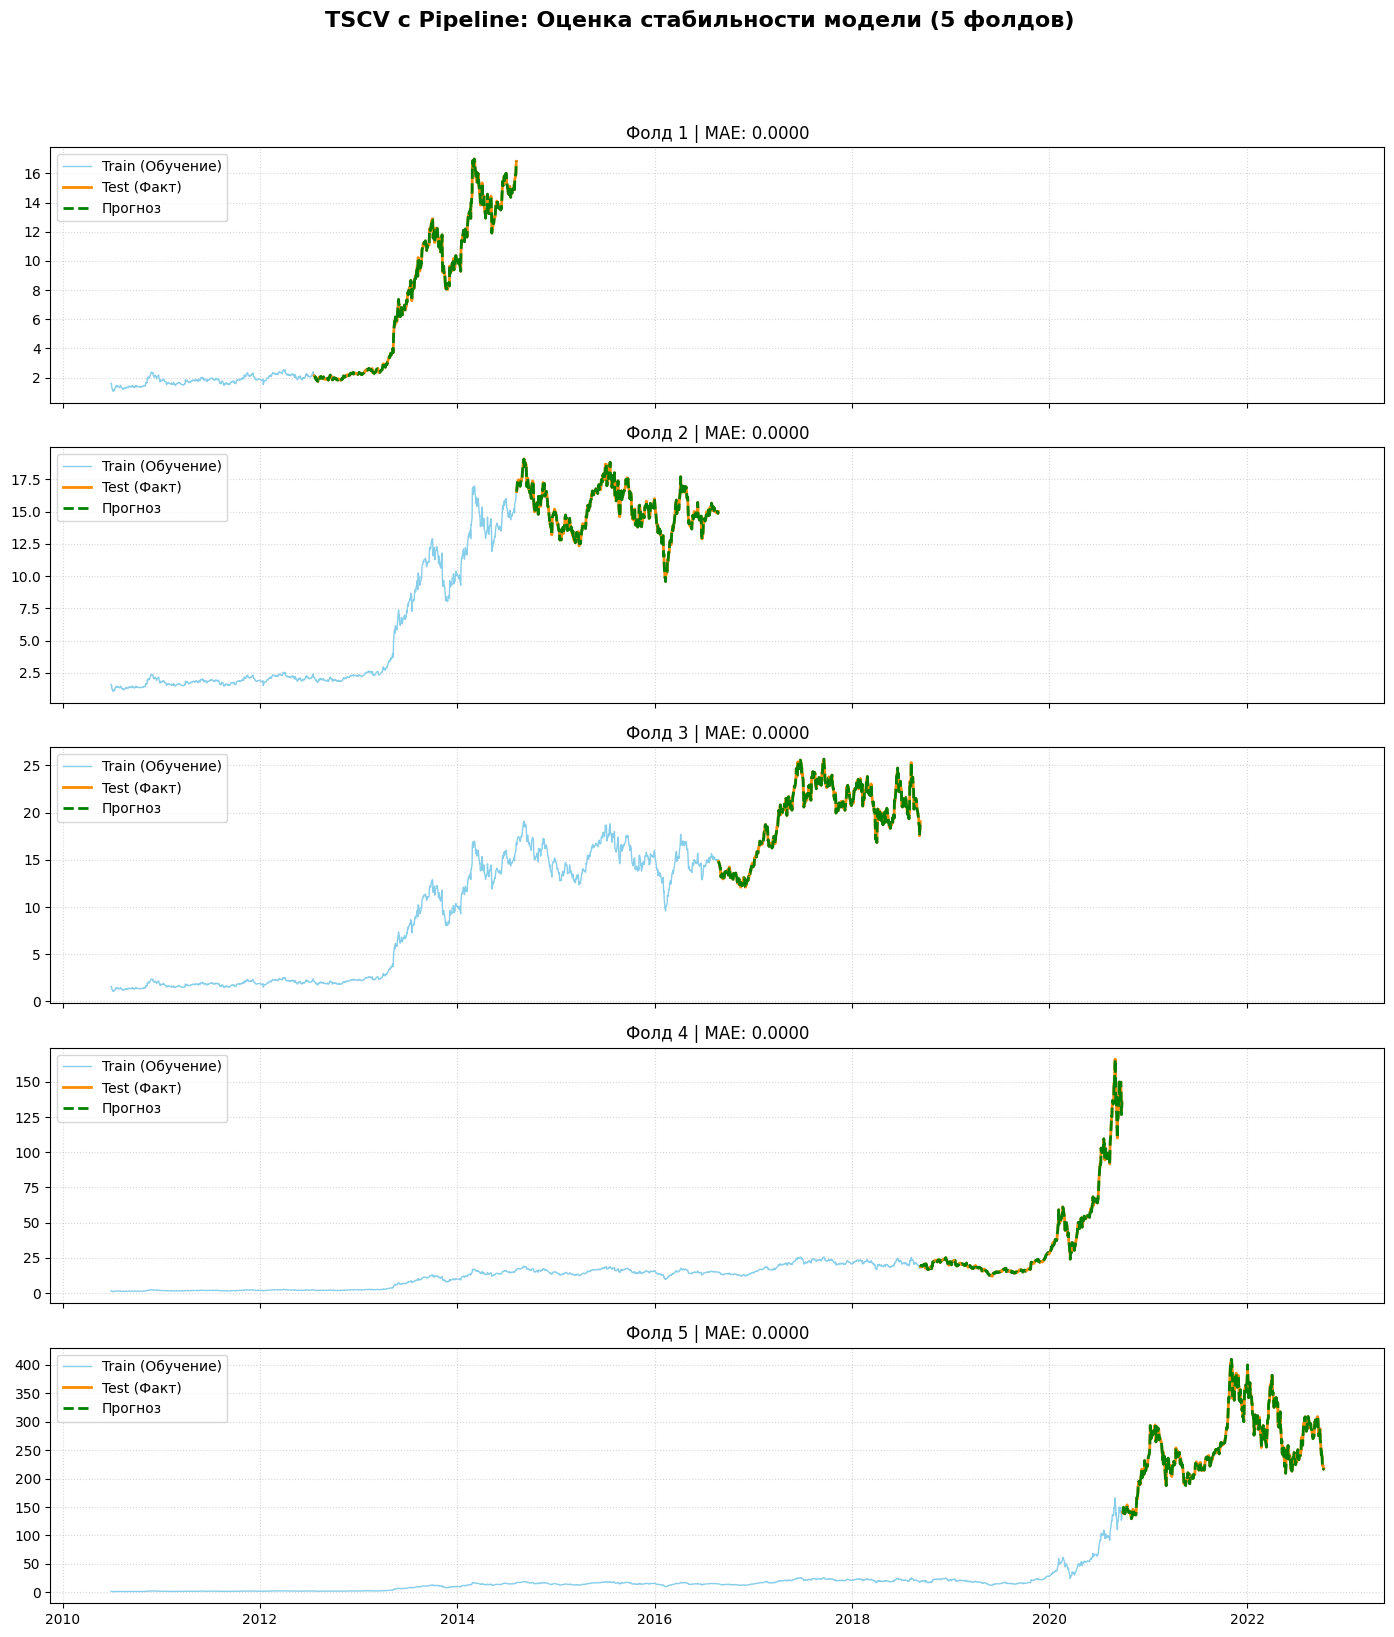

In [8]:
tscv = TimeSeriesSplit(n_splits=5)
mae_scores_full = []

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle('TSCV с Pipeline: Оценка стабильности модели (5 фолдов)', fontsize=16, fontweight='bold', y=1.02)

for fold, (train_index, test_index) in enumerate(tscv.split(X_train_val)):
    # Разделение данных
    X_train, X_test = X_train_val[train_index], X_train_val[test_index]
    y_train, y_test = y_train_val[train_index], y_train_val[test_index]

    # Обучите модель
    pipeline.fit(X_train, y_train)

    # Сделайте прогноз
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores_full.append(mae)

    # --- ВИЗУАЛИЗАЦИЯ ---
    ax = axes[fold]
    ax.plot(df_train_val.index[train_index], y_train, label='Train (Обучение)', color='skyblue', linewidth=1)
    ax.plot(df_train_val.index[test_index], y_test, label='Test (Факт)', color='darkorange', linewidth=2)
    ax.plot(df_train_val.index[test_index], y_pred, label='Прогноз', color='green', linestyle='--', linewidth=2)
    
    ax.set_title(f'Фолд {fold+1} | MAE: {mae:.4f}', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Интерпретация результатов


--- Результаты TimeSeriesSplit по фолдам ---
Фолд 1: MAE = 0.0000
Фолд 2: MAE = 0.0000
Фолд 3: MAE = 0.0000
Фолд 4: MAE = 0.0000
Фолд 5: MAE = 0.0000

Средняя MAE по всем фолдам: 0.0000


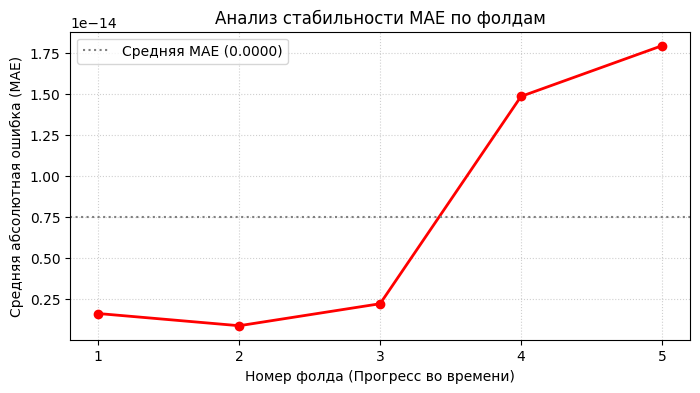

In [9]:
# --- АНАЛИЗ СТАБИЛЬНОСТИ МЕТРИК ---
print("\n--- Результаты TimeSeriesSplit по фолдам ---")
for i, mae in enumerate(mae_scores_full):
    print(f"Фолд {i+1}: MAE = {mae:.4f}")

avg_mae = np.mean(mae_scores_full)
print(f"\nСредняя MAE по всем фолдам: {avg_mae:.4f}")

# Визуализация стабильности
fold_numbers = np.arange(1, len(mae_scores_full) + 1)
plt.figure(figsize=(8, 4))
plt.plot(fold_numbers, mae_scores_full, marker='o', color='red', linewidth=2)
plt.axhline(y=avg_mae, color='gray', linestyle=':', label=f'Средняя MAE ({avg_mae:.4f})')
plt.title('Анализ стабильности MAE по фолдам')
plt.xlabel('Номер фолда (Прогресс во времени)')
plt.ylabel('Средняя абсолютная ошибка (MAE)')
plt.xticks(fold_numbers)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Финальная оценка


--- ФИНАЛЬНАЯ ОЦЕНКА НА OOT-ТЕСТЕ (252 ДНЕЙ) ---
Период OOT: с 2022-10-13 по 2023-10-13
--------------------------------------------------
1. MAE (Средняя абс. ошибка): 0.0000
2. RMSE (Корень из MSE): 0.0000
3. R² (Коэфф. детерминации): 1.0000 (Объясняющая сила)
--------------------------------------------------


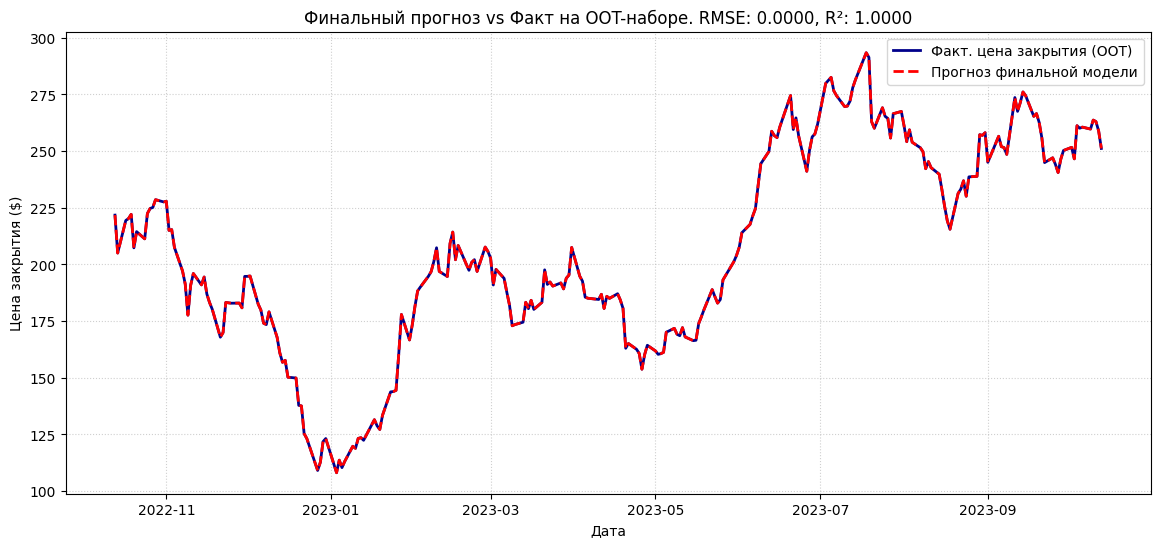

In [10]:
# Определяем наборы для финального теста (OOT)
X_oot = X[len(X_train_val):]
y_oot = y[len(y_train_val):]

# Обучение финального конвейера на всем наборе Train/Validation
final_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', LinearRegression())
])
final_pipeline.fit(X_train_val, y_train_val)

# Прогноз
y_pred_oot = final_pipeline.predict(X_oot)

# Расчет всех метрик
mae_oot = mean_absolute_error(y_oot, y_pred_oot)
mse_oot = mean_squared_error(y_oot, y_pred_oot)
rmse_oot = np.sqrt(mse_oot)
r2_oot = r2_score(y_oot, y_pred_oot)

print(f"\n--- ФИНАЛЬНАЯ ОЦЕНКА НА OOT-ТЕСТЕ ({len(X_oot)} ДНЕЙ) ---")
print(f"Период OOT: с {df_oot.index[0].date()} по {df_oot.index[-1].date()}")
print("-" * 50)
print(f"1. MAE (Средняя абс. ошибка): {mae_oot:.4f}")
print(f"2. RMSE (Корень из MSE): {rmse_oot:.4f}")
print(f"3. R² (Коэфф. детерминации): {r2_oot:.4f} (Объясняющая сила)")
print("-" * 50)

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(df_oot.index, y_oot, label='Факт. цена закрытия (OOT)', color='darkblue', linewidth=2)
plt.plot(df_oot.index, y_pred_oot, label='Прогноз финальной модели', color='red', linestyle='--', linewidth=2)
plt.title(f'Финальный прогноз vs Факт на OOT-наборе. RMSE: {rmse_oot:.4f}, R²: {r2_oot:.4f}')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()